In [ ]:
# ── Cell 1: Install dependencies ──────────────────────────────────────────────
import sys
print(f'Python version: {sys.version}')

# mediapipe 0.10.21 has a NameError bug on Python 3.12
# 0.10.9 is stable on Colab's Python 3.12
!pip install mediapipe==0.10.9 opencv-python-headless Pillow -q
print('✅ Done — now go to Runtime → Restart session, then run Cell 2 onwards')

Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
ERROR: Could not find a version that satisfies the requirement mediapipe==0.10.9 (from versions: 0.10.13, 0.10.14, 0.10.15, 0.10.18, 0.10.20, 0.10.21, 0.10.30, 0.10.31, 0.10.32)
ERROR: No matching distribution found for mediapipe==0.10.9
✅ Done — now go to Runtime → Restart session, then run Cell 2 onwards


In [ ]:
# ── Cell 2: Imports ────────────────────────────────────────────────────────────
import cv2
import numpy as np
import mediapipe as mp
from IPython.display import display, Javascript, Image
from google.colab.output import eval_js
from base64 import b64decode, b64encode
from PIL import Image as PILImage
import io

print('✅ All imports successful')
print(f'   MediaPipe version : {mp.__version__}')
print(f'   OpenCV version    : {cv2.__version__}')

✅ All imports successful
   MediaPipe version : 0.10.21
   OpenCV version    : 4.11.0


In [ ]:
# ── Cell 3: JavaScript helper — capture one frame from webcam ─────────────────
def take_photo(filename='photo.jpg', quality=0.92):
    js = Javascript('''
    async function takePhoto(filename, quality) {
        const div = document.createElement('div');
        const capture = document.createElement('button');
        capture.textContent = '📷 Capture Frame';
        capture.style.cssText = `
            padding:10px 24px; font-size:15px; cursor:pointer;
            background:#1a1a2e; color:#00ff88; border:1px solid #00ff88;
            border-radius:6px; font-family:monospace; margin:10px 0;
        `;
        div.appendChild(capture);

        const video = document.createElement('video');
        video.style.cssText = 'display:block; width:340px; margin:8px 0; border:1px solid #333; transform:scaleX(-1);';
        div.appendChild(video);
        document.body.appendChild(div);

        const stream = await navigator.mediaDevices.getUserMedia({video: {width:640, height:480}});
        video.srcObject = stream;
        await video.play();

        google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

        await new Promise(resolve => capture.onclick = resolve);

        const canvas = document.createElement('canvas');
        canvas.width  = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0);

        stream.getTracks().forEach(t => t.stop());
        div.remove();

        return canvas.toDataURL('image/jpeg', quality);
    }
    ''');
    display(js)
    data = eval_js(f'takePhoto("{filename}", {quality})')
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename

print('✅ take_photo() ready')

✅ take_photo() ready


In [ ]:
# ── Cell 4: MediaPipe setup ───────────────────────────────────────────────────
mp_face_mesh = mp.solutions.face_mesh
mp_drawing   = mp.solutions.drawing_utils
mp_styles    = mp.solutions.drawing_styles

face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode        = True,
    max_num_faces            = 1,
    refine_landmarks         = True,
    min_detection_confidence = 0.5
)

# ── Detection helpers ─────────────────────────────────────────────────────────

# Blink: vertical eye opening ratio
def is_blinking(landmarks, h, w):
    """Returns True if eyes appear closed (EAR threshold)."""
    # Left eye vertical distance: landmarks 159 (top) and 145 (bottom)
    top    = landmarks[159]
    bottom = landmarks[145]
    dist   = abs(top.y - bottom.y)
    return dist < 0.015

# Mouth: vertical lip distance
def is_mouth_open(landmarks):
    """Returns True if mouth is open."""
    top_lip    = landmarks[13]
    bottom_lip = landmarks[14]
    return abs(top_lip.y - bottom_lip.y) > 0.05

# Head direction: nose x-position relative to face width (mirrors notebook)
def get_head_direction(landmarks):
    """Returns: Looking Left / Looking Right / Looking Forward"""
    nose_x = landmarks[1].x   # normalised 0-1
    if nose_x < 0.4:
        return 'Looking Right'
    elif nose_x > 0.6:
        return 'Looking Left'
    else:
        return 'Looking Forward'

print('✅ MediaPipe FaceMesh initialised')
print('✅ Detection helpers ready (blink / mouth / head)')

✅ MediaPipe FaceMesh initialised
✅ Detection helpers ready (blink / mouth / head)


👉 Click the "Capture Frame" button below to take a photo...


<IPython.core.display.Javascript object>

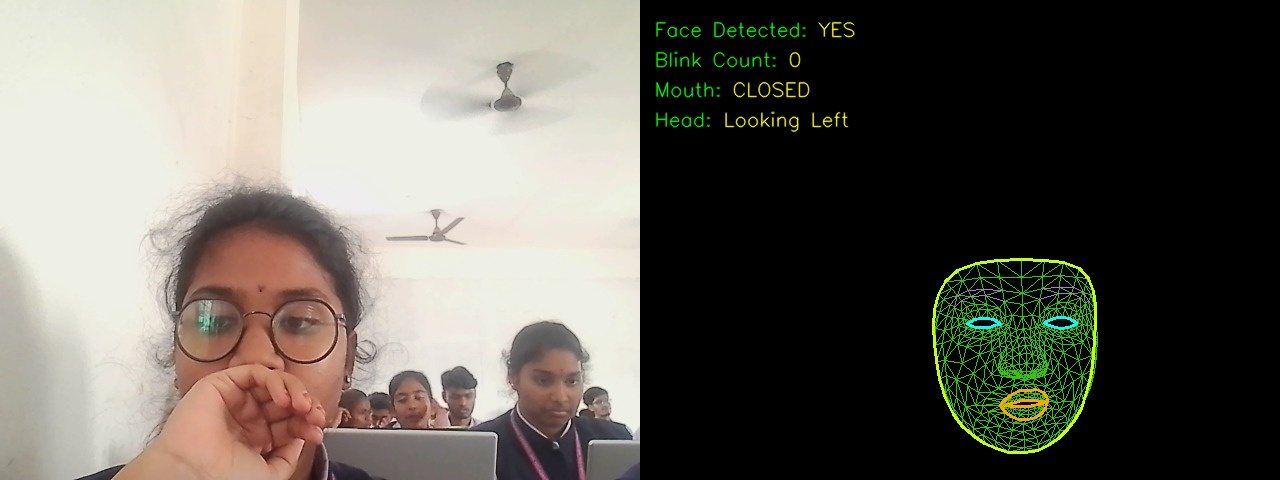


📊 Results:
   Face Detected : YES
   Blink Count   : 0
   Mouth         : CLOSED
   Head          : Looking Left


In [ ]:
# ── Cell 5: Main pipeline — capture + process + display ──────────────────────

blink_count = 0

# Capture frame from webcam
print('👉 Click the "Capture Frame" button below to take a photo...')
filename = take_photo('frame.jpg')

# Load captured frame
image_raw = cv2.imread(filename)
image_rgb = cv2.cvtColor(image_raw, cv2.COLOR_BGR2RGB)

h, w = image_raw.shape[:2]

# Run FaceMesh
results = face_mesh.process(image_rgb)

# ── Left panel: raw camera frame (mirrored to match reference) ────────────────
left_panel = cv2.flip(image_raw.copy(), 1)

# ── Right panel: black canvas with yellow wireframe mesh ─────────────────────
right_panel = np.zeros((h, w, 3), dtype=np.uint8)  # pure black

face_detected = False
mouth_status  = 'CLOSED'
head_dir      = 'Looking Forward'
blink_status  = False

if results.multi_face_landmarks:
    face_detected = True
    landmarks     = results.multi_face_landmarks[0].landmark

    # Draw YELLOW wireframe (tessellation + contours) on black canvas
    YELLOW = (0, 255, 255)   # OpenCV BGR — this renders as yellow

    # Draw tessellation (thin lines)
    mp_drawing.draw_landmarks(
        image            = right_panel,
        landmark_list    = results.multi_face_landmarks[0],
        connections      = mp_face_mesh.FACEMESH_TESSELATION,
        landmark_drawing_spec = None,
        connection_drawing_spec = mp_drawing.DrawingSpec(
            color=(0, 200, 50), thickness=1, circle_radius=0
        )
    )

    # Draw contours (brighter yellow, slightly thicker)
    for connections, color, thickness in [
        (mp_face_mesh.FACEMESH_FACE_OVAL,     (0, 255, 200), 2),
        (mp_face_mesh.FACEMESH_LEFT_EYE,      (255, 255, 0), 2),
        (mp_face_mesh.FACEMESH_RIGHT_EYE,     (255, 255, 0), 2),
        (mp_face_mesh.FACEMESH_LIPS,          (0, 165, 255), 2),
        (mp_face_mesh.FACEMESH_LEFT_EYEBROW,  (255, 100, 200), 1),
        (mp_face_mesh.FACEMESH_RIGHT_EYEBROW, (255, 100, 200), 1),
    ]:
        mp_drawing.draw_landmarks(
            image            = right_panel,
            landmark_list    = results.multi_face_landmarks[0],
            connections      = connections,
            landmark_drawing_spec = None,
            connection_drawing_spec = mp_drawing.DrawingSpec(
                color=color, thickness=thickness, circle_radius=0
            )
        )

    # ── Detections ────────────────────────────────────────────────────────────
    blink_status = is_blinking(landmarks, h, w)
    if blink_status:
        blink_count += 1

    mouth_open   = is_mouth_open(landmarks)
    mouth_status = 'OPEN' if mouth_open else 'CLOSED'
    head_dir     = get_head_direction(landmarks)

# ── Stats text overlay on RIGHT panel (matching reference format) ─────────────
GREEN  = (0, 255, 0)      # BGR
CYAN   = (255, 255, 0)    # BGR  — appears cyan in BGR
YELLOW_TXT = (0, 255, 255)

font       = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 0.65
thickness  = 1
x          = 14
y_start    = 36
line_gap   = 30

stats = [
    ('Face Detected: ', 'YES' if face_detected else 'NO'),
    ('Blink Count: ',   str(blink_count)),
    ('Mouth: ',         mouth_status),
    ('Head: ',          head_dir),
]

for i, (label, value) in enumerate(stats):
    y = y_start + i * line_gap
    # Draw label in green
    cv2.putText(right_panel, label, (x, y), font, font_scale, GREEN, thickness, cv2.LINE_AA)
    # Draw value in cyan (offset by label width)
    label_w, _ = cv2.getTextSize(label, font, font_scale, thickness)[0]
    cv2.putText(right_panel, value, (x + label_w, y), font, font_scale, YELLOW_TXT, thickness, cv2.LINE_AA)

# ── Combine panels side by side ───────────────────────────────────────────────
combined = np.hstack((left_panel, right_panel))

# ── Display in notebook ───────────────────────────────────────────────────────
combined_rgb = cv2.cvtColor(combined, cv2.COLOR_BGR2RGB)
pil_img      = PILImage.fromarray(combined_rgb)

buf = io.BytesIO()
pil_img.save(buf, format='JPEG', quality=95)
buf.seek(0)

display(Image(data=buf.read()))

# ── Print summary ─────────────────────────────────────────────────────────────
print(f'\n📊 Results:')
print(f'   Face Detected : {"YES" if face_detected else "NO"}')
print(f'   Blink Count   : {blink_count}')
print(f'   Mouth         : {mouth_status}')
print(f'   Head          : {head_dir}')

In [ ]:
# ── Cell 6 (Optional): Save output image ─────────────────────────────────────
output_path = 'face_mesh_output.jpg'
cv2.imwrite(output_path, combined)
print(f'✅ Output saved to {output_path}')

# Download it
from google.colab import files
files.download(output_path)

✅ Output saved to face_mesh_output.jpg


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ── Cell 7 (Optional): Run multiple captures in a loop ───────────────────────
# Uncomment and run this cell to capture N frames continuously

# NUM_FRAMES = 5
# blink_count = 0

# for i in range(NUM_FRAMES):
#     print(f'\n📸 Frame {i+1}/{NUM_FRAMES} — click button to capture')
#     fname   = take_photo(f'frame_{i}.jpg')
#     img_raw = cv2.imread(fname)
#     img_rgb = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)
#     h, w    = img_raw.shape[:2]
#     res     = face_mesh.process(img_rgb)
#     left    = cv2.flip(img_raw.copy(), 1)
#     right   = np.zeros((h, w, 3), dtype=np.uint8)
#     # ... (same processing as Cell 5) ...
#     combined = np.hstack((left, right))
#     display(Image(data=cv2.imencode('.jpg', combined)[1].tobytes()))